# Grib Select: Interactive Analysis

This notebook allows interactive comparison of weather models against local or METAR data.

### Setup

In [1]:
import sys
import os
# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from workflow import GribSelectorSession
%matplotlib inline

### 1. Initialize Session and Load Data

In [2]:
# show available grib files
os.listdir('./../tests/data/')

['gfs_0_25.2026-02-01T15-38-40Z.grb2.da267.idx',
 'model_A.nc',
 'gfs_0_25.2026-01-30T19-06-17Z.grb2.da267.idx',
 'local_log.csv',
 'gfs_0_25.2026-01-30T19-06-17Z.grb2',
 'gfs_0_25.2026-01-30T19-06-17Z.grb2.5b7b6.idx',
 'gfs_0_25.2026-02-01T15-38-40Z.grb2',
 'gfs_0_25.2026-02-01T15-38-40Z.grb2.5b7b6.idx']

In [3]:
session = GribSelectorSession()

# Load Local Data
session.load_local_data('../tests/data/local_log.csv')

# Load METAR (Optional)
session.load_metar('LDSP', hours=24) # Split
session.load_metar('LDZD', hours=24) # Zadar

# Add Models
session.add_grib('./../tests/data/gfs_0_25.2026-01-30T19-06-17Z.grb2')
session.add_grib('./../tests/data/gfs_0_25.2026-02-01T15-38-40Z.grb2')

# Show meta data of loaded grib files
print(30*'-')
session.report_grib()

01.02.2026 - 20:28:31
Session initialized.
Loaded 24 local data points.
Fetching METAR for LDSP...
Loaded 228 METAR records.
Fetching METAR for LDZD...
Loaded 180 METAR records.


Ignoring index file './../tests/data/gfs_0_25.2026-01-30T19-06-17Z.grb2.da267.idx' incompatible with GRIB file
Ignoring index file './../tests/data/gfs_0_25.2026-01-30T19-06-17Z.grb2.5b7b6.idx' incompatible with GRIB file


Added model: gfs_0_25.2026-01-30T19-06-17Z.grb2
Added model: gfs_0_25.2026-02-01T15-38-40Z.grb2
------------------------------
File                                     Start                End                  Lat Range       Lon Range      
-------------------------------------------------------------------------------------------------------------------
gfs_0_25.2026-01-30T19-06-17Z.grb2       2026-01-30 12:00:00  2026-02-04 12:00:00  [41.5, 45.8]   [12.8, 20.2]
gfs_0_25.2026-02-01T15-38-40Z.grb2       2026-02-01 06:00:00  2026-02-06 06:00:00  [41.5, 45.8]   [12.8, 20.2]


Listing Airport meteorologic data stations which are within the grib file range.

In [4]:
# After loading GRIBs
# stations = session.list_nearby_stations()
# returns a DataFrame with 'id', 'name', 'lat', 'lon'


# After loading GRIBs
import pandas as pd
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
stations = session.list_nearby_stations(grib_range_only=True)
print(stations.to_string())

Searching stations in Model Bounds (buffered): Lat [41.00, 46.25], Lon [12.25, 20.75]...
            id                                                                        name        lat        lon            type
7534   BA-0001                                          Bašigovci (Ciljuge Sport Airfield)  44.436094  18.686457   small_airport
7535   BA-0002                                                Banja Luka Zalužani Airfield  44.848200  17.222826   small_airport
7536   BA-0003                                                         Brčko-Brod Airfield  44.846235  18.761888   small_airport
7537   BA-0006                                                            Kreševo Airstrip  43.885661  18.068562   small_airport
7538   BA-0007                                                             Gorice Airfield  44.911565  18.738884   small_airport
7539   BA-0010                                                Suvo Polje (Dragon Airfield)  44.677670  19.129880   small_airport
7540   B

### 2. Run Analysis

**Display Metogram at selected Location**

Extracting time series for 121 time points...


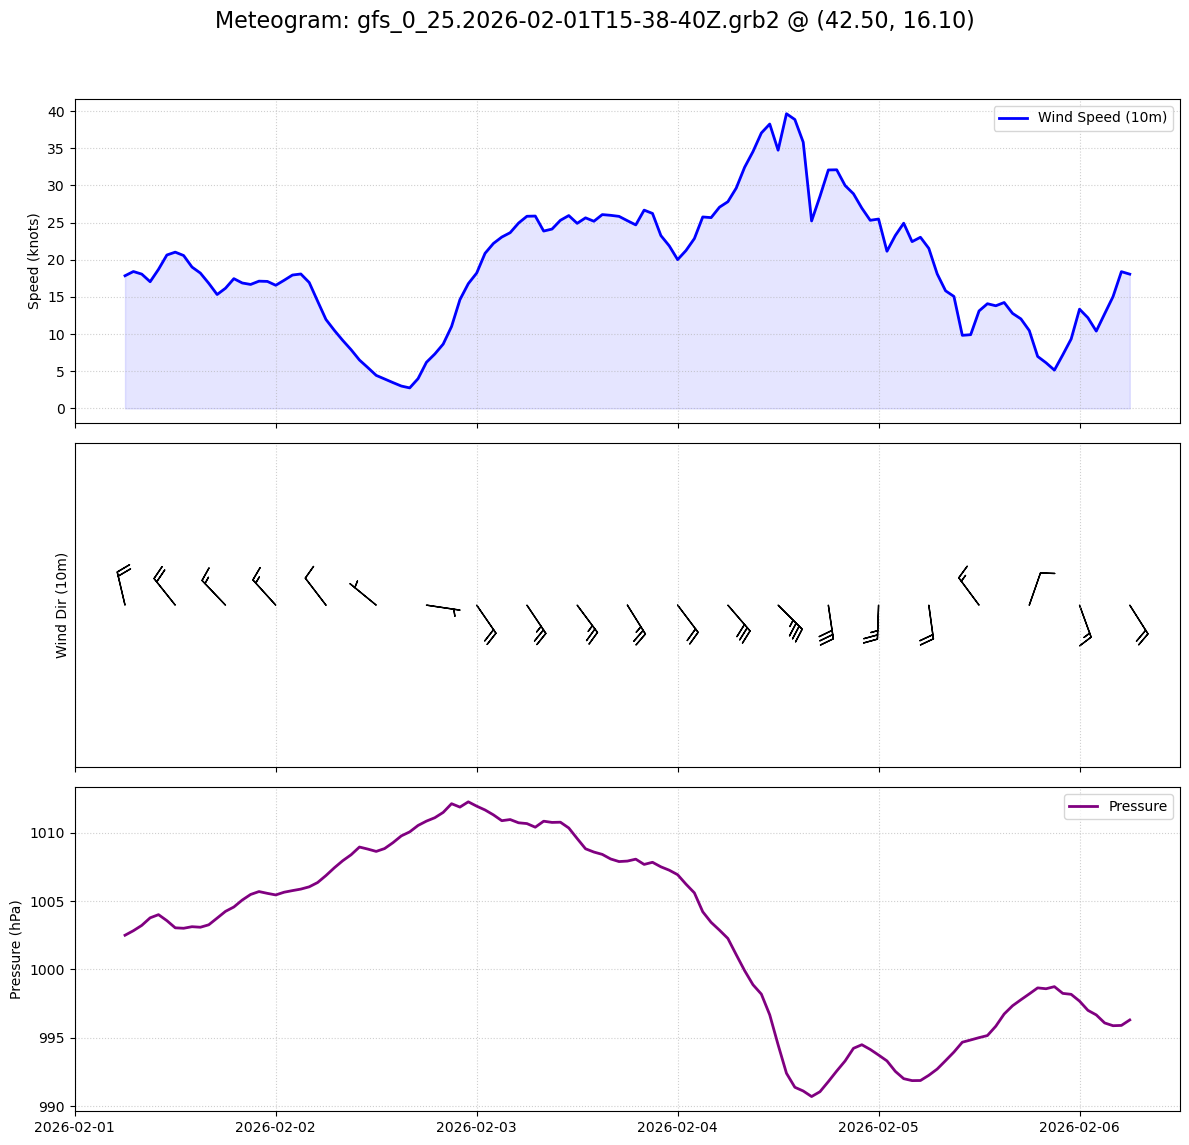

In [5]:
# reporting a meteogram at e.g. the current boat position
#position = [40, 16]
grib_file = "gfs_0_25.2026-02-01T15-38-40Z.grb2"
session.report_meteogram(grib_file, lat=42.5, lon=16.1)

In [6]:
session.run_comparison()

Running comparison...
Comparing 2 models vs 3 stations...


Processing Comparisons:   0%|          | 0/6 [00:00<?, ?it/s]

Comparison complete.


### 3. Dashboard
Interactive plot viewer.

In [ ]:
session.plot_interactive()

Note: To save all plots to 'output/' directory, run: session.save_plots()


In [9]:
session.save_plots()

Saving 3 plots to 'output/'...
  Saved: 20260201_202956_comparison_Local_Boat.png
  Saved: 20260201_202956_comparison_METAR_LDSP.png
  Saved: 20260201_202956_comparison_METAR_LDZD.png
Successfully saved 3 plots.


### 4. Ranking

In [10]:
session.get_ranking()


📊 RMSE Interpretation Guide:
   Wind: <3=Excellent, 3-5=Good, 5-8=Fair, 8-12=Poor, >12=Unreliable
   Pressure: <1=Excellent, 1-2=Good, >2=Poor



,Model,Station,Wind RMSE (kts),Quality,Pressure RMSE (hPa)
4,gfs_0_25.2026-01-30T19-06-17Z.grb2,METAR_LDZD,4.08,⭐⭐ Good,0.66
2,gfs_0_25.2026-01-30T19-06-17Z.grb2,METAR_LDSP,4.55,⭐⭐ Good,0.77
5,gfs_0_25.2026-02-01T15-38-40Z.grb2,METAR_LDZD,4.90,⭐⭐ Good,0.53
3,gfs_0_25.2026-02-01T15-38-40Z.grb2,METAR_LDSP,5.17,⭐ Fair,0.72
0,gfs_0_25.2026-01-30T19-06-17Z.grb2,Local_Boat,NaN,❌ Unreliable,NaN
1,gfs_0_25.2026-02-01T15-38-40Z.grb2,Local_Boat,NaN,❌ Unreliable,NaN
